**T1 - Tic Tac Toe com ML**

**Classificador k-NN (k vizinhos mais próximos)**

Classificação do estado do tabuleiro: Tem jogo, Jogador X venceu, Jogador O venceu e Empate.

Kamilah Santos e Amanda Wilmsen

Fluxo: ler os CSVs preparados → escolher os parâmetros na **validação** → avaliar uma única vez no **teste** → comparar as abordagens 1 e 2.
Executar de cima para baixo, com o notebook na raiz do repositório (ao lado da pasta `dataset`).

In [1]:
import time

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

**Configurações**

Abordagem 1: só as 9 casas do tabuleiro (b=0, x=1, o=-1). Abordagem 2: 15 características calculadas (qtd de X e O, posições ocupadas, linhas com 2 X/O, casas vazias e jogador da vez).

In [2]:
SEED = 42
BASE = "dataset/processado"   # pasta com os CSVs preparados

CLASSES = ["Tem jogo", "Jogador X venceu", "Jogador O venceu", "Empate"]
abordagens = {"abordagem_1": "A1 (tabuleiro)", "abordagem_2": "A2 (características)"}

**Carga dos dados**

Cada abordagem tem treino, validação e teste (já divididos fisicamente). As colunas `id_tabuleiro` (só identificador) e `estado` (a resposta) não entram como características.

In [3]:
dados = {}
for ab in abordagens:
    d = {}
    for conjunto, sufixo in [("treino", "train"), ("validacao", "val"), ("teste", "test")]:
        df = pd.read_csv(f"{BASE}/{ab}/{conjunto}.csv")
        d[f"ids_{sufixo}"] = df["id_tabuleiro"]
        d[f"y_{sufixo}"] = df["estado"].values
        d[f"X_{sufixo}"] = df.drop(columns=["id_tabuleiro", "estado"])
    dados[ab] = d

for ab in abordagens:
    print(abordagens[ab])
    print("  X_train:", dados[ab]["X_train"].shape, " y_train:", dados[ab]["y_train"].shape)
    print("  X_val:  ", dados[ab]["X_val"].shape, " y_val:  ", dados[ab]["y_val"].shape)
    print("  X_test: ", dados[ab]["X_test"].shape, " y_test: ", dados[ab]["y_test"].shape)

A1 (tabuleiro)
  X_train: (560, 9)  y_train: (560,)
  X_val:   (92, 9)  y_val:   (92,)
  X_test:  (93, 9)  y_test:  (93,)
A2 (características)
  X_train: (560, 15)  y_train: (560,)
  X_val:   (92, 15)  y_val:   (92,)
  X_test:  (93, 15)  y_test:  (93,)


In [4]:
# classes em cada conjunto
d = dados["abordagem_1"]
pd.DataFrame({"treino": pd.Series(d["y_train"]).value_counts(),
              "validacao": pd.Series(d["y_val"]).value_counts(),
              "teste": pd.Series(d["y_test"]).value_counts()})

,treino,validacao,teste
Empate,140,2,3
Jogador O venceu,140,30,30
Jogador X venceu,140,30,30
Tem jogo,140,30,30


In [5]:
# nenhum tabuleiro pode aparecer em mais de uma divisão (senão o teste seria "colado" do treino)
ids_train, ids_val, ids_test = set(d["ids_train"]), set(d["ids_val"]), set(d["ids_test"])
print("treino x validação:", len(ids_train & ids_val))
print("treino x teste:    ", len(ids_train & ids_test))
print("validação x teste: ", len(ids_val & ids_test))
print("linhas do treino:", len(d["ids_train"]), "- tabuleiros distintos:", len(ids_train),
      "(repetições = empates reamostrados no treino)")

treino x validação: 0
treino x teste:     0
validação x teste:  0
linhas do treino: 560 - tabuleiros distintos: 431 (repetições = empates reamostrados no treino)


**Métricas**

Acurácia, precision, recall e F-measure. Como a classe Empate tem pouquíssimos exemplos (3 no teste), usamos a média **macro** (cada classe pesa igual).

In [6]:
def metricas(y_real, y_pred):
    return {"acc": accuracy_score(y_real, y_pred),
            "precision": precision_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "recall": recall_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "f1_macro": f1_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0)}

**O algoritmo k-NN e os parâmetros a testar**

Para classificar um tabuleiro novo, o k-NN procura os `k` tabuleiros de treino mais parecidos (menor distância) e vota na classe mais comum entre eles. Não há uma fase de "aprender": o treino só guarda os exemplos e o trabalho acontece na predição (por isso a predição é mais lenta que a de uma árvore).

- `k`: nº de vizinhos. `k` pequeno acompanha demais o treino (overfitting); `k` grande suaviza demais.
- `metrica`: distância euclidiana ou de Manhattan.
- `pesos`: `uniform` (todos os vizinhos valem igual) ou `distance` (vizinhos mais próximos pesam mais).

**Escala:** na abordagem 2 as características misturam contagens (0 a 9) com indicadores (0/1); sem padronizar, as contagens dominariam a distância. Por isso a A2 usa `StandardScaler`, ajustado só no treino (dentro do pipeline). Na A1 todas as casas já estão em -1/0/1.

In [7]:
# valores testados (do mais simples ao mais complexo)
lista_k = [1, 3, 5, 7, 9, 11, 15]               # default 5
lista_metrica = ["euclidean", "manhattan"]      # default 'minkowski' (p=2 = euclidiana)
lista_pesos = ["uniform", "distance"]           # default 'uniform'

print("Combinações por abordagem:", len(lista_k) * len(lista_metrica) * len(lista_pesos))

Combinações por abordagem: 28


In [8]:
def criar_modelo(ab, k, metrica, pesos):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metrica, weights=pesos)
    if ab == "abordagem_2":
        return make_pipeline(StandardScaler(), knn)   # padroniza as características da A2
    return knn

**Ajuste de parâmetros na validação**

Treina um modelo para cada combinação, nas duas abordagens. O melhor é o de maior F1 macro na **validação** (desempate por acurácia; se ainda empatar, fica o primeiro, que é o mais simples). O teste não é usado aqui.

Guardamos também o F1 de treino: se for bem maior que o de validação, é sinal de overfitting.

In [9]:
resultados = []   # uma linha para cada combinação testada
melhor = {}       # melhor modelo de cada abordagem (escolhido pela validação)

for ab in abordagens:
    d = dados[ab]
    for k in lista_k:
        for metrica in lista_metrica:
            for pesos in lista_pesos:
                modelo = criar_modelo(ab, k, metrica, pesos)
                modelo.fit(d["X_train"], d["y_train"])
                m_train = metricas(d["y_train"], modelo.predict(d["X_train"]))
                m_val = metricas(d["y_val"], modelo.predict(d["X_val"]))

                resultados.append({"abordagem": abordagens[ab], "k": k, "metrica": metrica, "pesos": pesos,
                                   "f1_treino": m_train["f1_macro"],
                                   "val_acc": m_val["acc"], "val_f1_macro": m_val["f1_macro"]})

                chave = (m_val["f1_macro"], m_val["acc"])
                if ab not in melhor or chave > melhor[ab]["chave"]:
                    melhor[ab] = {"chave": chave, "f1_treino": m_train["f1_macro"], "modelo": modelo,
                                  "params": {"k": k, "metrica": metrica, "pesos": pesos}}

resultados = pd.DataFrame(resultados)
print("Combinações testadas:", len(resultados))

Combinações testadas: 56


In [10]:
# melhor configuração de cada abordagem
for ab in abordagens:
    print(abordagens[ab], "->", melhor[ab]["params"], " F1 validação =", round(melhor[ab]["chave"][0], 3))

A1 (tabuleiro) -> {'k': 7, 'metrica': 'manhattan', 'pesos': 'uniform'}  F1 validação = 0.643
A2 (características) -> {'k': 3, 'metrica': 'manhattan', 'pesos': 'uniform'}  F1 validação = 0.886


In [11]:
# as 5 melhores combinações de cada abordagem (validação)
for ab in abordagens:
    print(abordagens[ab])
    top = resultados[resultados.abordagem == abordagens[ab]].sort_values(["val_f1_macro", "val_acc"], ascending=False)
    display(top.head(5).round(3))

A1 (tabuleiro)


,abordagem,k,metrica,pesos,f1_treino,val_acc,val_f1_macro
14,A1 (tabuleiro),7,manhattan,uniform,0.821,0.707,0.643
15,A1 (tabuleiro),7,manhattan,distance,1.000,0.739,0.632
19,A1 (tabuleiro),9,manhattan,distance,1.000,0.696,0.617
23,A1 (tabuleiro),11,manhattan,distance,1.000,0.685,0.608
10,A1 (tabuleiro),5,manhattan,uniform,0.859,0.707,0.597


A2 (características)


,abordagem,k,metrica,pesos,f1_treino,val_acc,val_f1_macro
34,A2 (características),3,manhattan,uniform,0.948,0.859,0.886
38,A2 (características),5,manhattan,uniform,0.951,0.859,0.886
39,A2 (características),5,manhattan,distance,0.991,0.837,0.869
32,A2 (características),3,euclidean,uniform,0.931,0.837,0.868
47,A2 (características),9,manhattan,distance,0.991,0.837,0.867


**Avaliação final no teste**

A configuração escolhida na validação é avaliada **uma única vez** no teste. Medimos também o custo: tempo médio (20 repetições) de treino e de predição.

In [12]:
tabela = []
previsoes = {}

for ab in abordagens:
    d = dados[ab]
    modelo = melhor[ab]["modelo"]
    params = melhor[ab]["params"]

    # custo: tempo de treino e de predição
    t0 = time.perf_counter()
    for _ in range(20):
        criar_modelo(ab, **params).fit(d["X_train"], d["y_train"])
    tempo_treino = (time.perf_counter() - t0) / 20 * 1000
    t0 = time.perf_counter()
    for _ in range(20):
        modelo.predict(d["X_test"])
    tempo_pred = (time.perf_counter() - t0) / 20 * 1000

    # teste (uma única vez)
    previsoes[ab] = modelo.predict(d["X_test"])
    m = metricas(d["y_test"], previsoes[ab])
    tabela.append({"abordagem": abordagens[ab],
                   "acuracia": m["acc"], "precision": m["precision"], "recall": m["recall"], "f1_macro": m["f1_macro"],
                   "gap_treino_val": melhor[ab]["f1_treino"] - melhor[ab]["chave"][0],
                   "tempo_treino_ms": tempo_treino, "tempo_pred_ms": tempo_pred})

tabela = pd.DataFrame(tabela)
tabela.round(3)

,abordagem,acuracia,precision,recall,f1_macro,gap_treino_val,tempo_treino_ms,tempo_pred_ms
0,A1 (tabuleiro),0.667,0.562,0.517,0.523,0.179,1.787,2.416
1,A2 (características),0.860,0.891,0.892,0.890,0.061,3.183,2.506


**Resultado por classe e matriz de confusão (teste)**

Mostra onde o modelo erra. Atenção: o teste tem poucos empates, então as métricas dessa classe são instáveis (um único erro muda muito o valor).

In [13]:
for ab in abordagens:
    print(abordagens[ab])
    print(classification_report(dados[ab]["y_test"], previsoes[ab], labels=CLASSES, zero_division=0))

A1 (tabuleiro)
                  precision    recall  f1-score   support

        Tem jogo       0.83      0.50      0.62        30
Jogador X venceu       0.73      0.63      0.68        30
Jogador O venceu       0.68      0.93      0.79        30
          Empate       0.00      0.00      0.00         3

        accuracy                           0.67        93
       macro avg       0.56      0.52      0.52        93
    weighted avg       0.72      0.67      0.67        93

A2 (características)
                  precision    recall  f1-score   support

        Tem jogo       0.81      0.73      0.77        30
Jogador X venceu       0.78      0.83      0.81        30
Jogador O venceu       0.97      1.00      0.98        30
          Empate       1.00      1.00      1.00         3

        accuracy                           0.86        93
       macro avg       0.89      0.89      0.89        93
    weighted avg       0.86      0.86      0.86        93



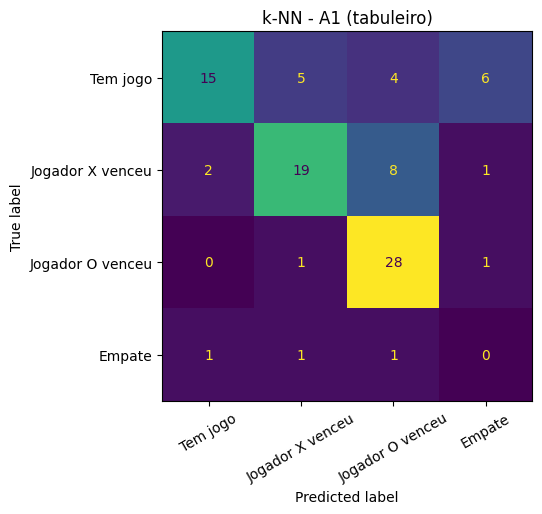

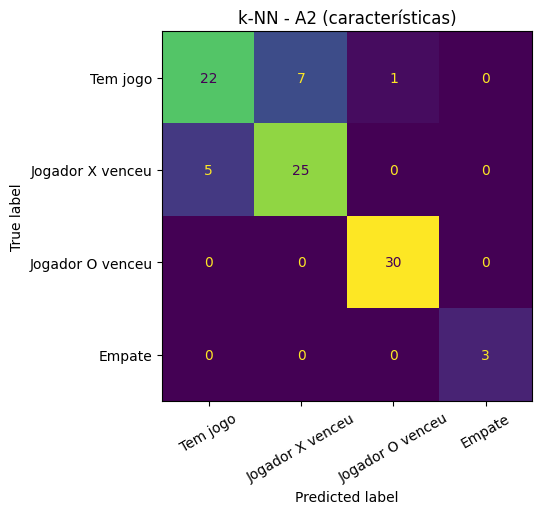

In [14]:
for ab in abordagens:
    resultado = confusion_matrix(dados[ab]["y_test"], previsoes[ab], labels=CLASSES)
    ConfusionMatrixDisplay(resultado, display_labels=CLASSES).plot(xticks_rotation=30, colorbar=False)
    plt.title(f"k-NN - {abordagens[ab]}")
    plt.show()

**Efeito do k (treino × validação)**

Para cada `k`, a melhor configuração. Se o F1 de treino for bem maior que o de validação, o modelo está decorando o treino (overfitting).

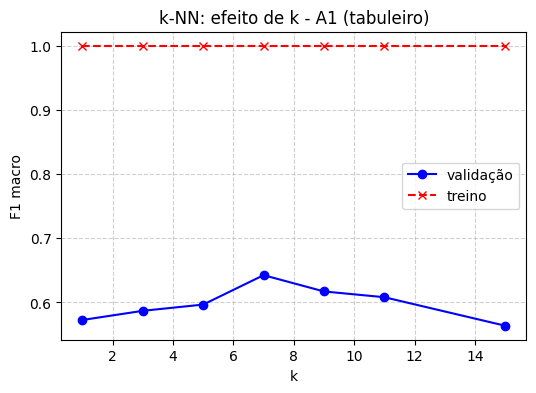

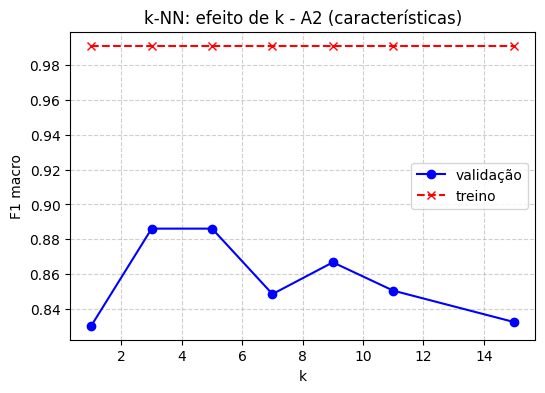

In [15]:
for ab in abordagens:
    s = resultados[resultados.abordagem == abordagens[ab]].groupby("k")[["f1_treino", "val_f1_macro"]].max()
    plt.figure(figsize=(6, 4))
    plt.plot(s.index, s["val_f1_macro"], label="validação", color="blue", marker="o", linestyle="-")
    plt.plot(s.index, s["f1_treino"], label="treino", color="red", marker="x", linestyle="--")
    plt.xlabel("k")
    plt.ylabel("F1 macro")
    plt.title(f"k-NN: efeito de k - {abordagens[ab]}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

In [16]:
# vizinhos mais próximos de um tabuleiro de teste (A1), para entender a decisão do k-NN
d = dados["abordagem_1"]
knn_a1 = melhor["abordagem_1"]["modelo"]
i = 0
dist, idx = knn_a1.kneighbors(d["X_test"].iloc[[i]])
print("Tabuleiro de teste:", d["ids_test"].iloc[i], "- classe real:", d["y_test"][i], "- previsto:", previsoes["abordagem_1"][i])
print("Vizinhos no treino:")
for dis, j in zip(dist[0], idx[0]):
    print("  ", d["ids_train"].iloc[j], d["y_train"][j], "distância =", round(dis, 2))

Tabuleiro de teste: xooxxbxbo - classe real: Jogador X venceu - previsto: Jogador X venceu
Vizinhos no treino:
   xboxxbxoo Jogador X venceu distância = 2.0
   xboxbbxbo Jogador X venceu distância = 2.0
   xooxbbbxo Tem jogo distância = 3.0
   xboxxobbo Jogador O venceu distância = 3.0
   xbooxbxbo Tem jogo distância = 3.0
   bboxxoxbo Jogador O venceu distância = 3.0
   xooxxxoxo Jogador X venceu distância = 4.0


**Comparação das abordagens (A1 × A2)**

Qual abordagem é mais adequada e menos custosa para este algoritmo?

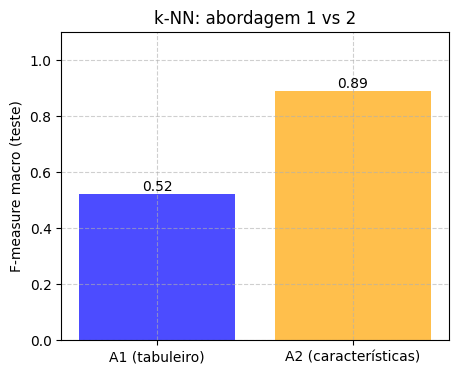

In [17]:
plt.figure(figsize=(5, 4))
plt.bar(tabela["abordagem"], tabela["f1_macro"], color=["blue", "orange"], alpha=0.7)
for i, v in enumerate(tabela["f1_macro"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.ylim(0, 1.1)
plt.ylabel("F-measure macro (teste)")
plt.title("k-NN: abordagem 1 vs 2")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [18]:
tabela[["abordagem", "acuracia", "f1_macro", "gap_treino_val", "tempo_treino_ms", "tempo_pred_ms"]].round(3)

,abordagem,acuracia,f1_macro,gap_treino_val,tempo_treino_ms,tempo_pred_ms
0,A1 (tabuleiro),0.667,0.523,0.179,1.787,2.416
1,A2 (características),0.860,0.890,0.061,3.183,2.506


**Para o relatório**

- Justificar cada parâmetro testado e a escolha final.
- Comparar A1 e A2 em desempenho (F1 macro no teste) **e** em custo (tempos).
- Comentar o overfitting com o gráfico do efeito de `k` e a coluna `gap_treino_val`.
- Ressalvar que a classe Empate tem poucos exemplos em validação e teste.